In [1]:
import pandas as pd
import numpy as np
import sqlite3
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Configura o caminho para o banco de dados
project_root = pathlib.Path("..") 
db_path = project_root / "banco de dados" / "crash_bot_historico.db"

print(f"Carregando dados de: {db_path}")

try:
    with sqlite3.connect(db_path) as conn:
        query = "SELECT timestamp, multiplicador FROM multiplicadores_historico ORDER BY timestamp ASC"
        df = pd.read_sql_query(query, conn, parse_dates=["timestamp"])
    
    df = df.set_index("timestamp").sort_index()
    print(f"Sucesso: {len(df)} rodadas carregadas do banco de dados.")
    
    print("\nÚltimas 5 rodadas carregadas:")
    display(df.tail())

except Exception as e:
    print(f"Erro ao carregar dados: {e}")

Carregando dados de: ..\banco de dados\crash_bot_historico.db
Sucesso: 105281 rodadas carregadas do banco de dados.

Últimas 5 rodadas carregadas:


,multiplicador
timestamp,
2026-01-12 10:59:18.988372,5.82
2026-01-12 10:59:37.730203,1.53
2026-01-12 11:00:04.503964,5.64
2026-01-12 11:00:29.862974,2.88
2026-01-12 11:00:44.898111,1.09


In [2]:
# --- CÉLULA 2: ESTATÍSTICAS DESCRITIVAS ---

print("="*70)
print("📊 ESTATÍSTICAS DESCRITIVAS DOS MULTIPLICADORES")
print("="*70)

print("\n📈 Estatísticas Básicas:")
display(df['multiplicador'].describe())

print(f"\n📌 Estatísticas Adicionais:")
print(f"  Mediana: {df['multiplicador'].median():.2f}x")
print(f"  Moda: {df['multiplicador'].mode().values[0]:.2f}x")
print(f"  Variância: {df['multiplicador'].var():.2f}")
print(f"  Assimetria (Skewness): {df['multiplicador'].skew():.2f}")
print(f"  Curtose: {df['multiplicador'].kurtosis():.2f}")

print(f"\n📊 Percentis Importantes:")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    valor = df['multiplicador'].quantile(p/100)
    print(f"  P{p}: {valor:.2f}x")

📊 ESTATÍSTICAS DESCRITIVAS DOS MULTIPLICADORES

📈 Estatísticas Básicas:


count    105281.000000
mean          6.193941
std          21.949156
min           1.000000
25%           1.270000
50%           1.890000
75%           4.990000
max         995.450000
Name: multiplicador, dtype: float64


📌 Estatísticas Adicionais:
  Mediana: 1.89x
  Moda: 1.53x
  Variância: 481.77
  Assimetria (Skewness): 12.97
  Curtose: 314.01

📊 Percentis Importantes:
  P1: 1.00x
  P5: 1.04x
  P10: 1.09x
  P25: 1.27x
  P50: 1.89x
  P75: 4.99x
  P90: 7.81x
  P95: 9.93x
  P99: 129.36x


In [3]:
# --- CÉLULA 3: ANÁLISE DE TARGETS ---

print("="*70)
print("🎯 PROBABILIDADE DE ATINGIR CADA TARGET")
print("="*70)

targets = [1.5, 1.8, 1.9, 1.95, 1.99, 2.0, 2.05, 2.1, 2.5, 3.0, 5.0, 10.0]

print(f"\n{'Target':<10} {'Prob (%)':<12} {'Frequência':<12} {'Observação'}")
print("-"*60)

resultados_targets = []
for target in targets:
    prob = (df['multiplicador'] >= target).mean() * 100
    freq = (df['multiplicador'] >= target).sum()
    resultados_targets.append({'target': target, 'prob': prob, 'freq': freq})
    
    if target == 1.99:
        obs = "← TARGET ATUAL"
    elif target == 2.0:
        obs = "← LIMITE BAIXA/ALTA"
    elif target == 2.05:
        obs = "← TARGET OTIMIZADO?"
    else:
        obs = ""
    
    print(f"{target:.2f}x      {prob:>6.2f}%      {freq:>8,}    {obs}")

df_targets = pd.DataFrame(resultados_targets)
display(df_targets)

🎯 PROBABILIDADE DE ATINGIR CADA TARGET

Target     Prob (%)     Frequência   Observação
------------------------------------------------------------
1.50x       67.36%        70,922    
1.80x       53.66%        56,490    
1.90x       49.62%        52,243    
1.95x       47.60%        50,115    
1.99x       45.97%        48,398    ← TARGET ATUAL
2.00x       45.55%        47,958    ← LIMITE BAIXA/ALTA
2.05x       44.65%        47,007    ← TARGET OTIMIZADO?
2.10x       44.00%        46,320    
2.50x       38.58%        40,617    
3.00x       32.48%        34,196    
5.00x       24.99%        26,305    
10.00x        4.88%         5,139    


,target,prob,freq
0,1.50,67.364482,70922
1,1.80,53.656405,56490
2,1.90,49.622439,52243
3,1.95,47.601182,50115
4,1.99,45.970308,48398
5,2.00,45.552379,47958
6,2.05,44.649082,47007
7,2.10,43.996543,46320
8,2.50,38.579611,40617
9,3.00,32.480695,34196


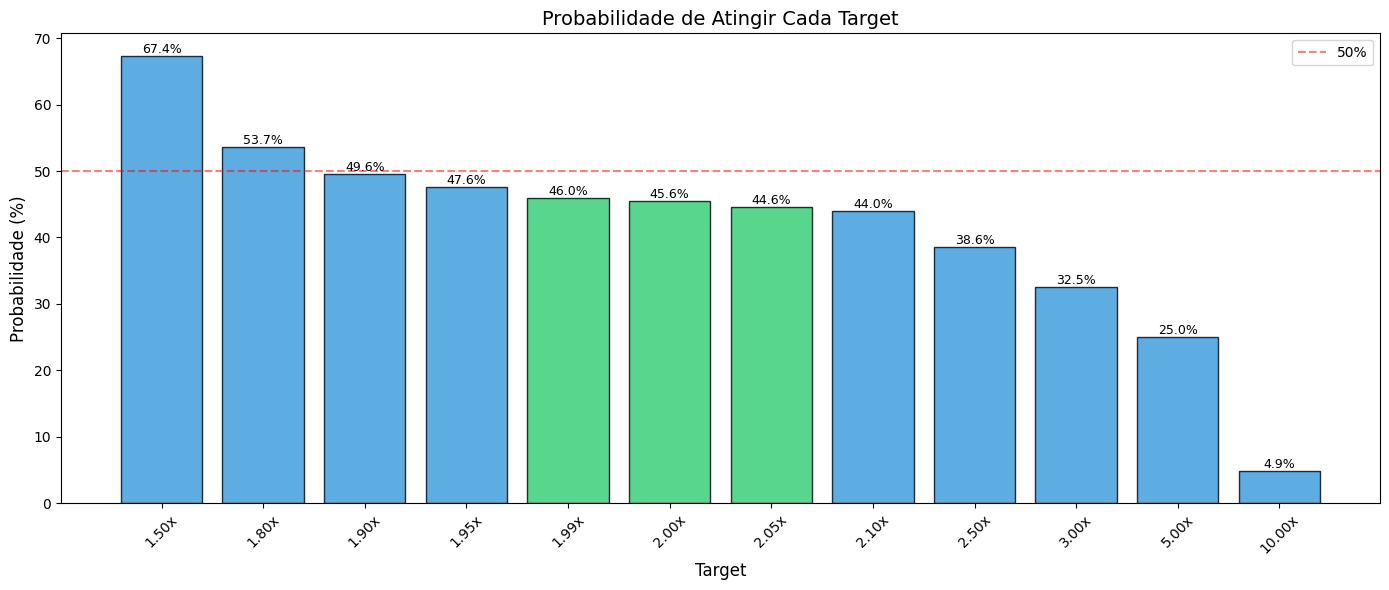


📁 Gráfico salvo: 01_probabilidade_targets.png


In [4]:
# --- CÉLULA 4: GRÁFICO DE PROBABILIDADE DE TARGETS ---

plt.figure(figsize=(14, 6))

cores = ['#3498db'] * len(targets)
for i, t in enumerate(targets):
    if t in [1.99, 2.0, 2.05]:
        cores[i] = '#2ecc71'  # Verde para targets importantes

bars = plt.bar(range(len(targets)), df_targets['prob'], color=cores, alpha=0.8, edgecolor='black')

plt.xticks(range(len(targets)), [f"{t:.2f}x" for t in targets], rotation=45)
plt.ylabel('Probabilidade (%)', fontsize=12)
plt.xlabel('Target', fontsize=12)
plt.title('Probabilidade de Atingir Cada Target', fontsize=14)
plt.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50%')

for i, (t, p) in enumerate(zip(targets, df_targets['prob'])):
    plt.annotate(f'{p:.1f}%', xy=(i, p), ha='center', va='bottom', fontsize=9)

plt.legend()
plt.tight_layout()
plt.savefig('01_probabilidade_targets.png', dpi=150)
plt.show()

print("\n📁 Gráfico salvo: 01_probabilidade_targets.png")

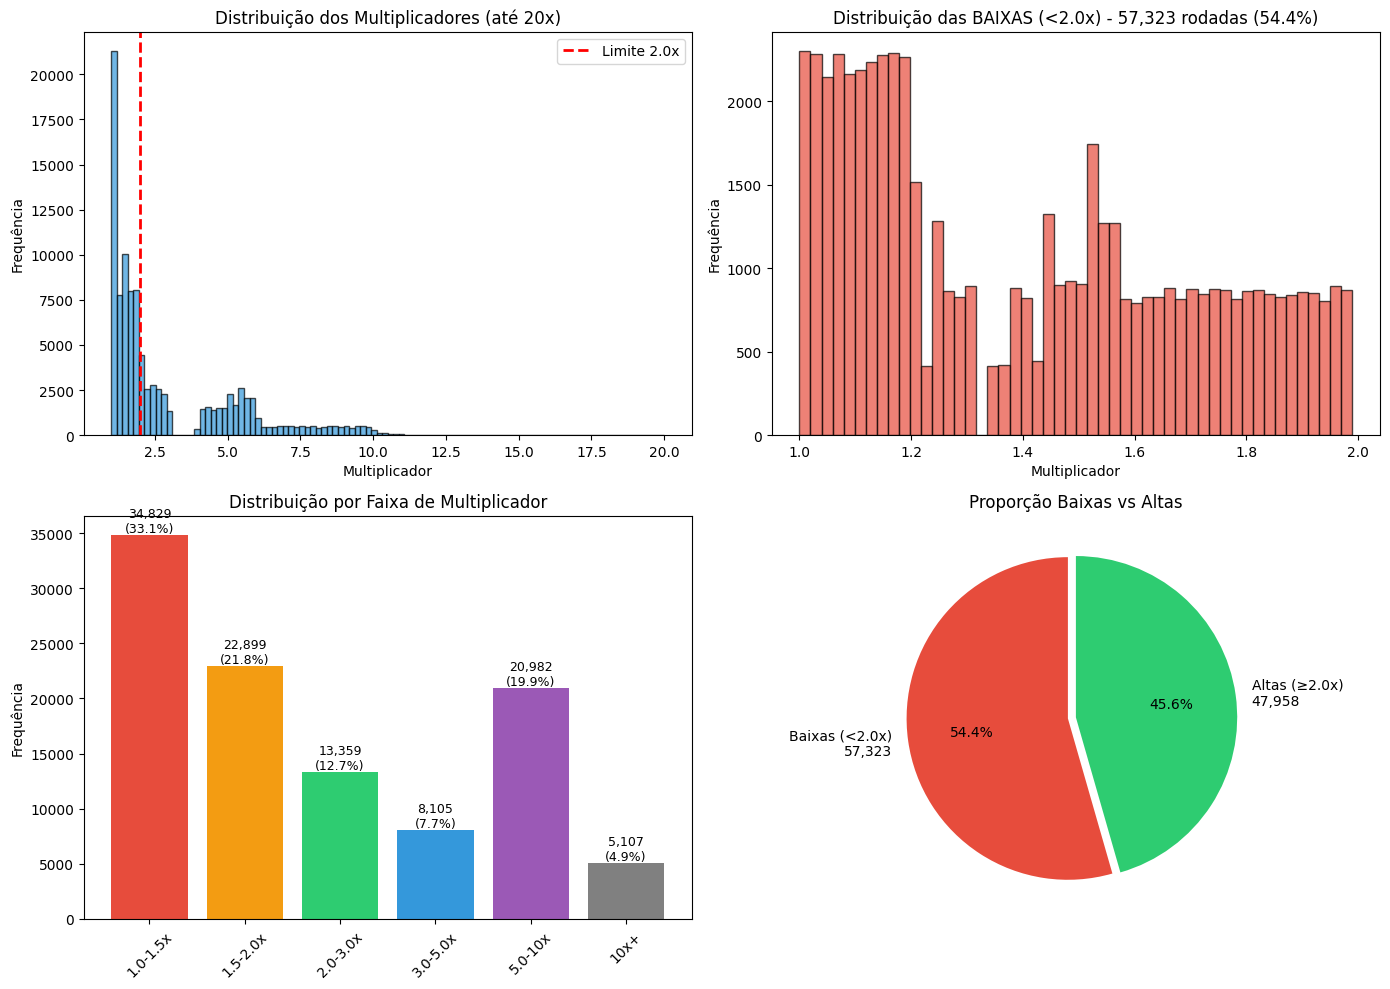


📁 Gráfico salvo: 02_distribuicao_multiplicadores.png


In [5]:
# --- CÉLULA 5: DISTRIBUIÇÃO DOS MULTIPLICADORES ---

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histograma geral (até 20x)
ax1 = axes[0, 0]
df_plot = df[df['multiplicador'] <= 20]
ax1.hist(df_plot['multiplicador'], bins=100, color='#3498db', alpha=0.7, edgecolor='black')
ax1.axvline(x=2.0, color='red', linestyle='--', linewidth=2, label='Limite 2.0x')
ax1.set_xlabel('Multiplicador')
ax1.set_ylabel('Frequência')
ax1.set_title('Distribuição dos Multiplicadores (até 20x)')
ax1.legend()

# 2. Histograma das baixas (<2.0x)
ax2 = axes[0, 1]
df_baixas = df[df['multiplicador'] < 2.0]
pct_baixas = len(df_baixas) / len(df) * 100
ax2.hist(df_baixas['multiplicador'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Multiplicador')
ax2.set_ylabel('Frequência')
ax2.set_title(f'Distribuição das BAIXAS (<2.0x) - {len(df_baixas):,} rodadas ({pct_baixas:.1f}%)')

# 3. Por faixa
ax3 = axes[1, 0]
df['faixa'] = pd.cut(df['multiplicador'], 
                     bins=[0, 1.5, 2.0, 3.0, 5.0, 10.0, float('inf')],
                     labels=['1.0-1.5x', '1.5-2.0x', '2.0-3.0x', '3.0-5.0x', '5.0-10x', '10x+'])
faixa_counts = df['faixa'].value_counts().sort_index()
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db', '#9b59b6', 'gray']
bars = ax3.bar(range(len(faixa_counts)), faixa_counts.values, color=colors)
ax3.set_xticks(range(len(faixa_counts)))
ax3.set_xticklabels(faixa_counts.index, rotation=45)
ax3.set_ylabel('Frequência')
ax3.set_title('Distribuição por Faixa de Multiplicador')
for i, v in enumerate(faixa_counts.values):
    ax3.annotate(f'{v:,}\n({v/len(df)*100:.1f}%)', xy=(i, v), ha='center', va='bottom', fontsize=9)

# 4. Pizza Baixas vs Altas
ax4 = axes[1, 1]
baixas = (df['multiplicador'] < 2.0).sum()
altas = (df['multiplicador'] >= 2.0).sum()
ax4.pie([baixas, altas], 
        labels=[f'Baixas (<2.0x)\n{baixas:,}', f'Altas (≥2.0x)\n{altas:,}'],
        colors=['#e74c3c', '#2ecc71'], 
        autopct='%1.1f%%', 
        startangle=90,
        explode=(0.05, 0))
ax4.set_title('Proporção Baixas vs Altas')

plt.tight_layout()
plt.savefig('02_distribuicao_multiplicadores.png', dpi=150)
plt.show()

print("\n📁 Gráfico salvo: 02_distribuicao_multiplicadores.png")

In [6]:
# --- CÉLULA 6: ANÁLISE POR HORÁRIO ---

print("="*70)
print("🕐 ANÁLISE POR HORÁRIO")
print("="*70)

# Adicionar colunas temporais
df['hora'] = df.index.hour
df['is_baixa'] = df['multiplicador'] < 2.0

# Estatísticas por hora
stats_hora = df.groupby('hora').agg({
    'multiplicador': ['count', 'mean', 'std'],
    'is_baixa': 'mean'
}).round(3)
stats_hora.columns = ['rodadas', 'media', 'std', 'pct_baixas']
stats_hora['pct_baixas'] = stats_hora['pct_baixas'] * 100

print("\n📊 Estatísticas por Hora:")
display(stats_hora)

# Melhores e piores horários
melhor_hora = stats_hora['pct_baixas'].idxmin()
pior_hora = stats_hora['pct_baixas'].idxmax()

print(f"\n✅ MELHOR horário: {melhor_hora:02d}:00 ({stats_hora.loc[melhor_hora, 'pct_baixas']:.1f}% baixas)")
print(f"❌ PIOR horário: {pior_hora:02d}:00 ({stats_hora.loc[pior_hora, 'pct_baixas']:.1f}% baixas)")
print(f"📊 Diferença: {stats_hora.loc[pior_hora, 'pct_baixas'] - stats_hora.loc[melhor_hora, 'pct_baixas']:.1f}%")

🕐 ANÁLISE POR HORÁRIO

📊 Estatísticas por Hora:


,rodadas,media,std,pct_baixas
hora,,,,
0,4795,6.055,19.253,54.4
1,4961,5.612,17.487,55.4
2,5249,6.705,23.354,54.8
3,5361,6.182,21.809,54.7
4,1545,6.164,19.705,53.3
5,1903,5.893,18.248,52.2
6,2176,5.525,17.383,54.1
7,2688,6.717,28.637,54.8
8,3605,6.192,24.547,53.8



✅ MELHOR horário: 05:00 (52.2% baixas)
❌ PIOR horário: 16:00 (56.0% baixas)
📊 Diferença: 3.8%


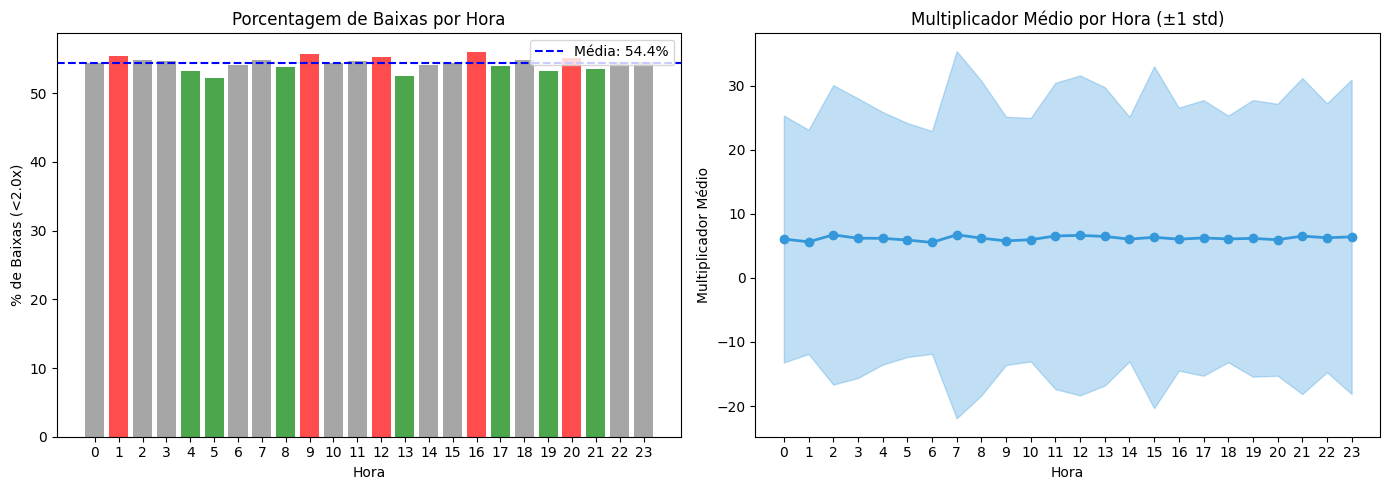


📁 Gráfico salvo: 03_analise_por_hora.png


In [7]:
# --- CÉLULA 7: GRÁFICO DE ANÁLISE POR HORÁRIO ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de % de baixas por hora
ax1 = axes[0]
colors = ['green' if x < 54 else 'red' if x > 55 else 'gray' for x in stats_hora['pct_baixas']]
ax1.bar(stats_hora.index, stats_hora['pct_baixas'], color=colors, alpha=0.7)
ax1.axhline(y=stats_hora['pct_baixas'].mean(), color='blue', linestyle='--', 
            label=f'Média: {stats_hora["pct_baixas"].mean():.1f}%')
ax1.set_xlabel('Hora')
ax1.set_ylabel('% de Baixas (<2.0x)')
ax1.set_title('Porcentagem de Baixas por Hora')
ax1.set_xticks(range(24))
ax1.legend()

# Gráfico de média por hora
ax2 = axes[1]
ax2.plot(stats_hora.index, stats_hora['media'], marker='o', color='#3498db', linewidth=2)
ax2.fill_between(stats_hora.index, 
                  stats_hora['media'] - stats_hora['std'], 
                  stats_hora['media'] + stats_hora['std'], 
                  alpha=0.3, color='#3498db')
ax2.set_xlabel('Hora')
ax2.set_ylabel('Multiplicador Médio')
ax2.set_title('Multiplicador Médio por Hora (±1 std)')
ax2.set_xticks(range(24))

plt.tight_layout()
plt.savefig('03_analise_por_hora.png', dpi=150)
plt.show()

print("\n📁 Gráfico salvo: 03_analise_por_hora.png")

In [8]:
# --- CÉLULA 8: ANÁLISE DE SEQUÊNCIAS DE BAIXAS ---

print("="*70)
print("📈 ANÁLISE DE SEQUÊNCIAS DE BAIXAS CONSECUTIVAS")
print("="*70)

TARGET_MULTIPLIER = 2.0

# Calcular low_streak
is_low = df['multiplicador'] < TARGET_MULTIPLIER
cumulative_lows = is_low.astype(int).cumsum()
streak_breaks = cumulative_lows.where(~is_low)
filled_breaks = streak_breaks.ffill().fillna(0)
df['low_streak'] = (cumulative_lows - filled_breaks).astype(int)

# Identificar tamanho de cada sequência
sequences = []
current_max = 0
for val in df['low_streak'].values:
    if val > current_max:
        current_max = val
    elif val == 0 and current_max > 0:
        sequences.append(current_max)
        current_max = 0
if current_max > 0:
    sequences.append(current_max)

print(f"\n📊 Total de sequências de baixas: {len(sequences):,}")
print(f"📊 Sequência mais longa: {max(sequences)} baixas consecutivas")

# Distribuição
seq_counts = Counter(sequences)

print(f"\n📊 Distribuição das Sequências:")
print(f"{'Tamanho':<12} {'Quantidade':<12} {'Porcentagem':<12} {'Relevância'}")
print("-"*65)

for size in sorted(seq_counts.keys()):
    count = seq_counts[size]
    pct = count / len(sequences) * 100
    
    if size == 6:
        relevancia = "← GATILHO ENTRADA"
    elif size >= 9 and size < 12:
        relevancia = "← CICLO 2 RECUPERA"
    elif size >= 12:
        relevancia = "← QUEBRA TOTAL!"
    else:
        relevancia = ""
    
    print(f"{size:<12} {count:<12,} {pct:<11.2f}% {relevancia}")

📈 ANÁLISE DE SEQUÊNCIAS DE BAIXAS CONSECUTIVAS

📊 Total de sequências de baixas: 26,157
📊 Sequência mais longa: 12 baixas consecutivas

📊 Distribuição das Sequências:
Tamanho      Quantidade   Porcentagem  Relevância
-----------------------------------------------------------------
1            11,746       44.91      % 
2            6,595        25.21      % 
3            3,550        13.57      % 
4            1,926        7.36       % 
5            1,069        4.09       % 
6            679          2.60       % ← GATILHO ENTRADA
7            318          1.22       % 
8            153          0.58       % 
9            71           0.27       % ← CICLO 2 RECUPERA
10           31           0.12       % ← CICLO 2 RECUPERA
11           13           0.05       % ← CICLO 2 RECUPERA
12           6            0.02       % ← QUEBRA TOTAL!


In [9]:
# --- CÉLULA 9: ESTATÍSTICAS PARA ESTRATÉGIA ---

print("="*70)
print("🎯 ESTATÍSTICAS PARA ESTRATÉGIA 1-2-4-1-2-4")
print("="*70)

seq_6_plus = sum(1 for s in sequences if s >= 6)
seq_7_plus = sum(1 for s in sequences if s >= 7)
seq_8_plus = sum(1 for s in sequences if s >= 8)
seq_9_plus = sum(1 for s in sequences if s >= 9)
seq_10_plus = sum(1 for s in sequences if s >= 10)
seq_11_plus = sum(1 for s in sequences if s >= 11)
seq_12_plus = sum(1 for s in sequences if s >= 12)

print(f"\n📊 Distribuição de Entradas e Resultados:")
print(f"  Sequências de 6+ baixas (GATILHO): {seq_6_plus:,}")
print(f"\n  Vitórias no Ciclo 1 (6-8 baixas):")
print(f"    - Dobra 1 (6 baixas): {seq_6_plus - seq_7_plus:,} ({(seq_6_plus - seq_7_plus)/seq_6_plus*100:.1f}%)")
print(f"    - Dobra 2 (7 baixas): {seq_7_plus - seq_8_plus:,} ({(seq_7_plus - seq_8_plus)/seq_6_plus*100:.1f}%)")
print(f"    - Dobra 3 (8 baixas): {seq_8_plus - seq_9_plus:,} ({(seq_8_plus - seq_9_plus)/seq_6_plus*100:.1f}%)")
print(f"\n  Recuperações no Ciclo 2 (9-11 baixas):")
print(f"    - Dobra 4 (9 baixas): {seq_9_plus - seq_10_plus:,} ({(seq_9_plus - seq_10_plus)/seq_6_plus*100:.1f}%)")
print(f"    - Dobra 5 (10 baixas): {seq_10_plus - seq_11_plus:,} ({(seq_10_plus - seq_11_plus)/seq_6_plus*100:.1f}%)")
print(f"    - Dobra 6 (11 baixas): {seq_11_plus - seq_12_plus:,} ({(seq_11_plus - seq_12_plus)/seq_6_plus*100:.1f}%)")
print(f"\n  💀 QUEBRAS (12+ baixas): {seq_12_plus:,} ({seq_12_plus/seq_6_plus*100:.2f}%)")
print(f"\n  ✅ TAXA DE VITÓRIA: {(seq_6_plus - seq_12_plus)/seq_6_plus*100:.2f}%")

🎯 ESTATÍSTICAS PARA ESTRATÉGIA 1-2-4-1-2-4

📊 Distribuição de Entradas e Resultados:
  Sequências de 6+ baixas (GATILHO): 1,271

  Vitórias no Ciclo 1 (6-8 baixas):
    - Dobra 1 (6 baixas): 679 (53.4%)
    - Dobra 2 (7 baixas): 318 (25.0%)
    - Dobra 3 (8 baixas): 153 (12.0%)

  Recuperações no Ciclo 2 (9-11 baixas):
    - Dobra 4 (9 baixas): 71 (5.6%)
    - Dobra 5 (10 baixas): 31 (2.4%)
    - Dobra 6 (11 baixas): 13 (1.0%)

  💀 QUEBRAS (12+ baixas): 6 (0.47%)

  ✅ TAXA DE VITÓRIA: 99.53%


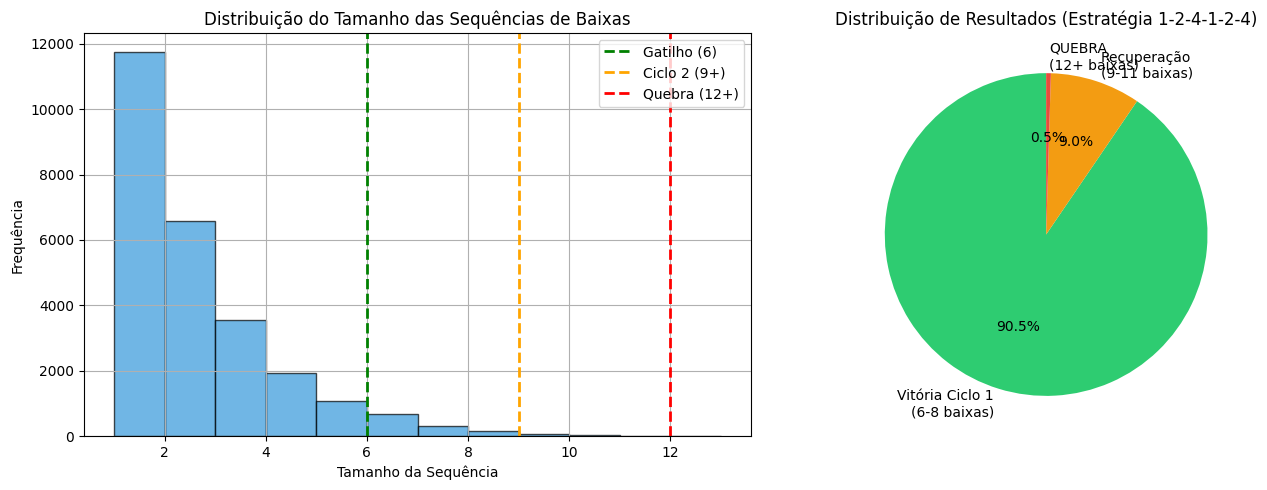


📁 Gráfico salvo: 04_analise_sequencias.png


In [10]:
# --- CÉLULA 10: VISUALIZAÇÃO DE SEQUÊNCIAS ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histograma de sequências
ax1 = axes[0]
seq_df = pd.DataFrame({'tamanho': sequences})
seq_df['tamanho'].hist(bins=range(1, max(sequences)+2), ax=ax1, color='#3498db', 
                        alpha=0.7, edgecolor='black')
ax1.axvline(x=6, color='green', linestyle='--', linewidth=2, label='Gatilho (6)')
ax1.axvline(x=9, color='orange', linestyle='--', linewidth=2, label='Ciclo 2 (9+)')
ax1.axvline(x=12, color='red', linestyle='--', linewidth=2, label='Quebra (12+)')
ax1.set_xlabel('Tamanho da Sequência')
ax1.set_ylabel('Frequência')
ax1.set_title('Distribuição do Tamanho das Sequências de Baixas')
ax1.legend()

# 2. Pizza de resultados
ax2 = axes[1]
resultados = {
    'Vitória Ciclo 1\n(6-8 baixas)': sum(1 for s in sequences if 6 <= s <= 8),
    'Recuperação\n(9-11 baixas)': sum(1 for s in sequences if 9 <= s <= 11),
    'QUEBRA\n(12+ baixas)': sum(1 for s in sequences if s >= 12)
}
colors_pie = ['#2ecc71', '#f39c12', '#e74c3c']
ax2.pie(resultados.values(), labels=resultados.keys(), colors=colors_pie, 
        autopct='%1.1f%%', startangle=90)
ax2.set_title('Distribuição de Resultados (Estratégia 1-2-4-1-2-4)')

plt.tight_layout()
plt.savefig('04_analise_sequencias.png', dpi=150)
plt.show()

print("\n📁 Gráfico salvo: 04_analise_sequencias.png")

In [11]:
# --- CÉLULA 11: RESUMO FINAL ---

print("="*70)
print("📋 RESUMO DA ANÁLISE EXPLORATÓRIA")
print("="*70)

print(f"""
📊 DADOS:
   - Total de rodadas: {len(df):,}
   - Período: {df.index.min().strftime('%Y-%m-%d')} até {df.index.max().strftime('%Y-%m-%d')}
   - Multiplicador médio: {df['multiplicador'].mean():.2f}x
   - Baixas (<2.0x): {(df['multiplicador']<2.0).mean()*100:.1f}%

🎯 TARGETS:
   - P(≥1.99x): {(df['multiplicador'] >= 1.99).mean()*100:.1f}%
   - P(≥2.00x): {(df['multiplicador'] >= 2.0).mean()*100:.1f}%
   - P(≥2.05x): {(df['multiplicador'] >= 2.05).mean()*100:.1f}%

📈 ESTRATÉGIA 1-2-4-1-2-4:
   - Entradas potenciais (6+ baixas): {seq_6_plus:,}
   - Vitórias Ciclo 1 (6-8 baixas): {sum(1 for s in sequences if 6 <= s <= 8):,}
   - Recuperações Ciclo 2 (9-11 baixas): {sum(1 for s in sequences if 9 <= s <= 11):,}
   - QUEBRAS (12+ baixas): {seq_12_plus}
   - Taxa de Vitória: {(seq_6_plus - seq_12_plus)/seq_6_plus*100:.2f}%

🕐 HORÁRIOS:
   - Melhor: {melhor_hora:02d}:00 ({stats_hora.loc[melhor_hora, 'pct_baixas']:.1f}% baixas)
   - Pior: {pior_hora:02d}:00 ({stats_hora.loc[pior_hora, 'pct_baixas']:.1f}% baixas)
""")

# Salvar dados processados
df.to_csv('dados_processados_analise.csv')
print("\n📁 Dados salvos: dados_processados_analise.csv")

📋 RESUMO DA ANÁLISE EXPLORATÓRIA

📊 DADOS:
   - Total de rodadas: 105,281
   - Período: 2025-11-28 até 2026-01-12
   - Multiplicador médio: 6.19x
   - Baixas (<2.0x): 54.4%

🎯 TARGETS:
   - P(≥1.99x): 46.0%
   - P(≥2.00x): 45.6%
   - P(≥2.05x): 44.6%

📈 ESTRATÉGIA 1-2-4-1-2-4:
   - Entradas potenciais (6+ baixas): 1,271
   - Vitórias Ciclo 1 (6-8 baixas): 1,150
   - Recuperações Ciclo 2 (9-11 baixas): 115
   - QUEBRAS (12+ baixas): 6
   - Taxa de Vitória: 99.53%

🕐 HORÁRIOS:
   - Melhor: 05:00 (52.2% baixas)
   - Pior: 16:00 (56.0% baixas)


📁 Dados salvos: dados_processados_analise.csv
